# EDA · Consumo de los hogares españoles y precios (EPF + IPC 2024)

Análisis exploratorio del conjunto `epf_ipc_2024_final.csv`, que une el gasto
real de los hogares (EPF) con la evolución de precios por categoría (IPC), a
nivel **hogar × grupo de gasto**.

**Todos los resultados se ponderan por `FACTOR`** (factor de elevación de la
EPF), para que representen al conjunto de hogares de España y no solo a la
muestra.

Estructura: (1) descriptivo · (2) segmentación · (3) territorio ·
(4) consumo × inflación · (5) análisis estadístico.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "font.size": 10})

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG = BASE / "figuras"; FIG.mkdir(exist_ok=True)
CSV = BASE / "FINALES" / "epf_ipc_2024_final.csv"

df = pd.read_csv(CSV)
print(f"Filas: {len(df):,} | Columnas: {df.shape[1]} | Hogares: {df['NUMERO'].nunique():,}")

Filas: 212,173 | Columnas: 49 | Hogares: 19,410


## Utilidades de ponderación
La EPF es una muestra; `FACTOR` eleva cada hogar a la población. Definimos la
media y los cuantiles ponderados, y una media ponderada por grupos.

In [3]:
def wmean(v, w):
    v, w = np.asarray(v, float), np.asarray(w, float)
    m = ~np.isnan(v)
    return np.average(v[m], weights=w[m])

def wquantile(v, w, q):
    v, w = np.asarray(v, float), np.asarray(w, float)
    o = np.argsort(v); v, w = v[o], w[o]
    c = np.cumsum(w) - 0.5 * w; c /= w.sum()
    return np.interp(q, c, v)

def wmean_by(frame, by, val, w="FACTOR"):
    t = frame.assign(_n=frame[val] * frame[w])
    return t.groupby(by, observed=True)["_n"].sum() / t.groupby(by, observed=True)[w].sum()

# Órdenes de las variables ordinales (para que los gráficos no salgan alfabéticos)
ORD_ING = ["Menos de 500 €","500 – 1.000 €","1.000 – 1.500 €","1.500 – 2.000 €",
           "2.000 – 2.500 €","2.500 – 3.000 €","3.000 – 5.000 €","5.000 – 7.000 €",
           "7.000 – 9.000 €","9.000 € y más","No consta"]
ORD_EST = ["Inferior a 1ª etapa de Secundaria","Primera etapa de Secundaria",
           "Segunda etapa de Secundaria","Educación Superior"]
ORD_MUNI = ["100.000 hab. o más","50.000 – 100.000 hab.","20.000 – 50.000 hab.",
            "10.000 – 20.000 hab.","Menos de 10.000 hab."]
ORD_TAM = ["Una persona","Dos personas","Tres personas","Cuatro personas",
           "Cinco personas","Seis o más personas"]

# Tabla a nivel HOGAR (una fila por hogar) para los análisis de hogar
hog = (df.groupby("NUMERO").agg(
        FACTOR=("FACTOR","first"), gasto_eur=("gasto_grupo_eur","sum"),
        ingresos=("intervalo_ingresos","first"), tam_hogar=("tamano_hogar","first"),
        tenencia=("regimen_tenencia","first"), estudios=("nivel_estudios_sp","first"),
        sexo=("sexo_sp","first"), edad_sp=("EDADSP","first"), ccaa=("ccaa_nombre","first"),
        tam_muni=("tamano_municipio","first"), zona=("zona_residencia","first"),
        nmiemb=("NMIEMB","first"), superf=("SUPERF","first"), nhabit=("NHABIT","first"),
        uc1=("UC1","first"), interin_cod=("INTERIN","first"), est_cod=("ESTUDREDSP","first"))
       .reset_index())

## Bloque 1 · Estructura del gasto (descriptivo)
### 1.1 ¿Cuánto gasta un hogar y cómo se distribuye?

Gasto medio por hogar : 34,044 €/año
Mediana               : 29,468 €/año
P10 – P90             : 14,155 € – 59,486 €
Asimetría (media>mediana => cola a la derecha): 4,576 € de diferencia


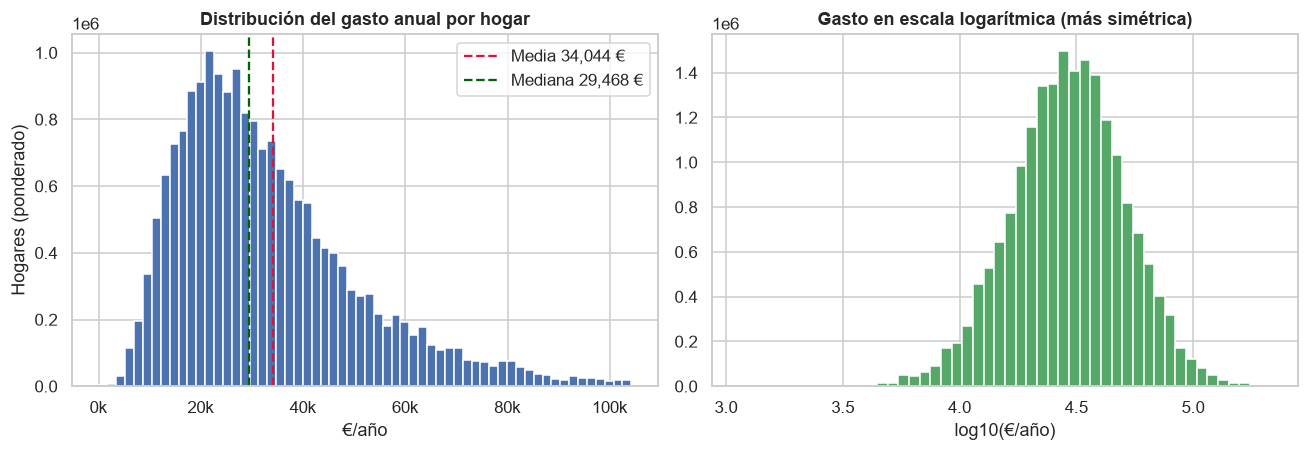

In [4]:
media = wmean(hog.gasto_eur, hog.FACTOR)
mediana = wquantile(hog.gasto_eur, hog.FACTOR, 0.5)
p10 = wquantile(hog.gasto_eur, hog.FACTOR, 0.10)
p90 = wquantile(hog.gasto_eur, hog.FACTOR, 0.90)
print(f"Gasto medio por hogar : {media:,.0f} €/año")
print(f"Mediana               : {mediana:,.0f} €/año")
print(f"P10 – P90             : {p10:,.0f} € – {p90:,.0f} €")
print(f"Asimetría (media>mediana => cola a la derecha): {media-mediana:,.0f} € de diferencia")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
top = wquantile(hog.gasto_eur, hog.FACTOR, 0.99)
ax[0].hist(hog.gasto_eur, bins=60, range=(0, top), weights=hog.FACTOR, color="#4C72B0")
ax[0].axvline(media, color="crimson", ls="--", lw=1.5, label=f"Media {media:,.0f} €")
ax[0].axvline(mediana, color="darkgreen", ls="--", lw=1.5, label=f"Mediana {mediana:,.0f} €")
ax[0].set(title="Distribución del gasto anual por hogar", xlabel="€/año", ylabel="Hogares (ponderado)")
ax[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax[0].legend()
ax[1].hist(np.log10(hog.gasto_eur[hog.gasto_eur > 0]), bins=50,
           weights=hog.FACTOR[hog.gasto_eur > 0], color="#55A868")
ax[1].set(title="Gasto en escala logarítmica (más simétrica)", xlabel="log10(€/año)", ylabel="")
plt.tight_layout(); plt.savefig(FIG/"fig01_distribucion_gasto.png", bbox_inches="tight"); plt.show()

### 1.2 ¿En qué se va el presupuesto? (peso de cada grupo)

grupo_nombre
Bebidas alcohólicas y tabaco                               1.3
Enseñanza                                                  1.6
Información y comunicaciones                               3.2
Cuidado personal, protección social y otros                3.6
Seguros y servicios financieros                            3.7
Muebles, artículos del hogar y mantenimiento del hogar     3.7
Sanidad                                                    4.0
Vestido y calzado                                          4.2
Actividades recreativas, deporte y cultura                 5.0
Restaurantes y servicios de alojamiento                    9.9
Transporte                                                11.4
Alimentos y bebidas no alcohólicas                        15.8
Vivienda, agua, electricidad, gas y otros combustibles    32.4


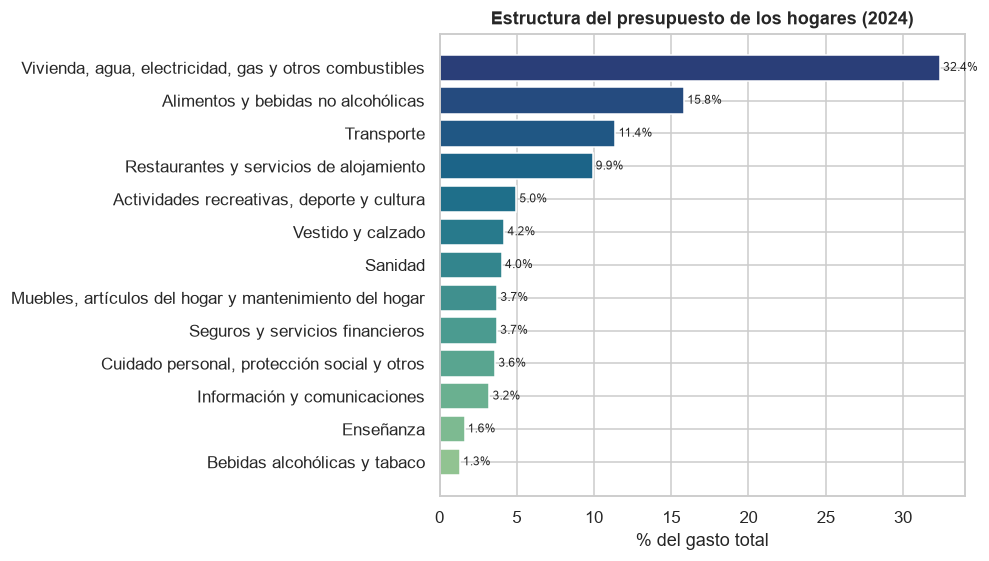

In [5]:
peso = df.groupby("grupo_nombre")["gasto_grupo_elev"].sum()
peso = (peso / peso.sum() * 100).sort_values()
print(peso.round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.barh(peso.index, peso.values, color=sns.color_palette("crest", len(peso)))
for i, v in enumerate(peso.values):
    ax.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=8)
ax.set(title="Estructura del presupuesto de los hogares (2024)", xlabel="% del gasto total")
plt.tight_layout(); plt.savefig(FIG/"fig02_estructura_presupuesto.png", bbox_inches="tight"); plt.show()

### 1.3 ¿Cómo son los hogares? (perfil socioeconómico)

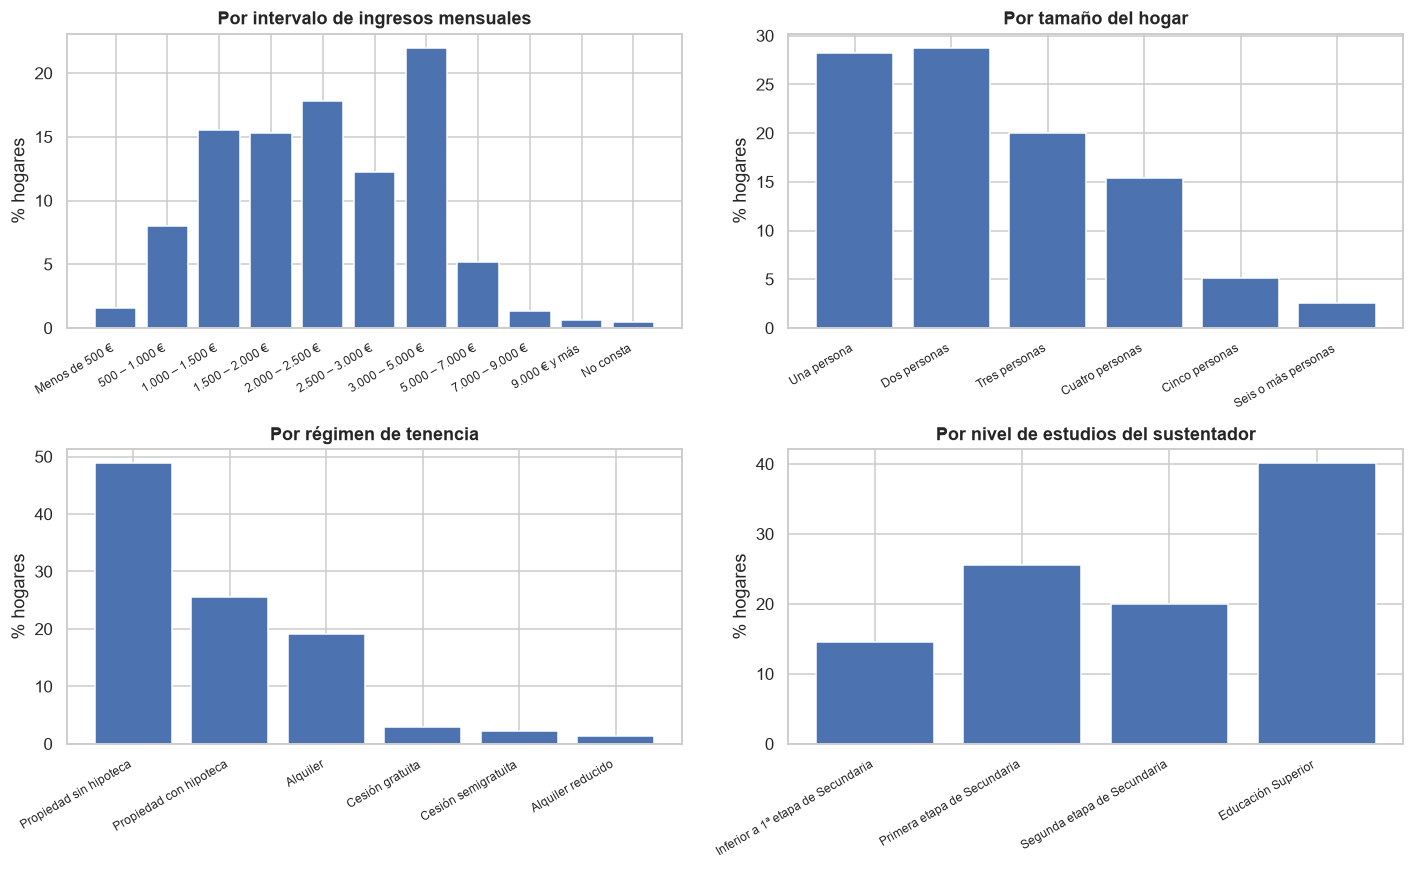

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
def barra_ponderada(ax, col, orden, titulo):
    s = hog.groupby(col, observed=True)["FACTOR"].sum()
    s = s.reindex([o for o in orden if o in s.index]) if orden else s.sort_values(ascending=False)
    s = s / s.sum() * 100
    ax.bar(range(len(s)), s.values, color="#4C72B0")
    ax.set_xticks(range(len(s))); ax.set_xticklabels(s.index, rotation=30, ha="right", fontsize=8)
    ax.set(title=titulo, ylabel="% hogares")
barra_ponderada(axes[0,0], "ingresos", ORD_ING, "Por intervalo de ingresos mensuales")
barra_ponderada(axes[0,1], "tam_hogar", ORD_TAM, "Por tamaño del hogar")
barra_ponderada(axes[1,0], "tenencia", None, "Por régimen de tenencia")
barra_ponderada(axes[1,1], "estudios", ORD_EST, "Por nivel de estudios del sustentador")
plt.tight_layout(); plt.savefig(FIG/"fig03_perfil_hogares.png", bbox_inches="tight"); plt.show()

## Bloque 2 · Gasto según el perfil del hogar (segmentación)
### 2.1 Curvas de Engel: la composición cambia con la renta
A mayor renta, ¿baja el peso de la alimentación y sube el de ocio/restauración?

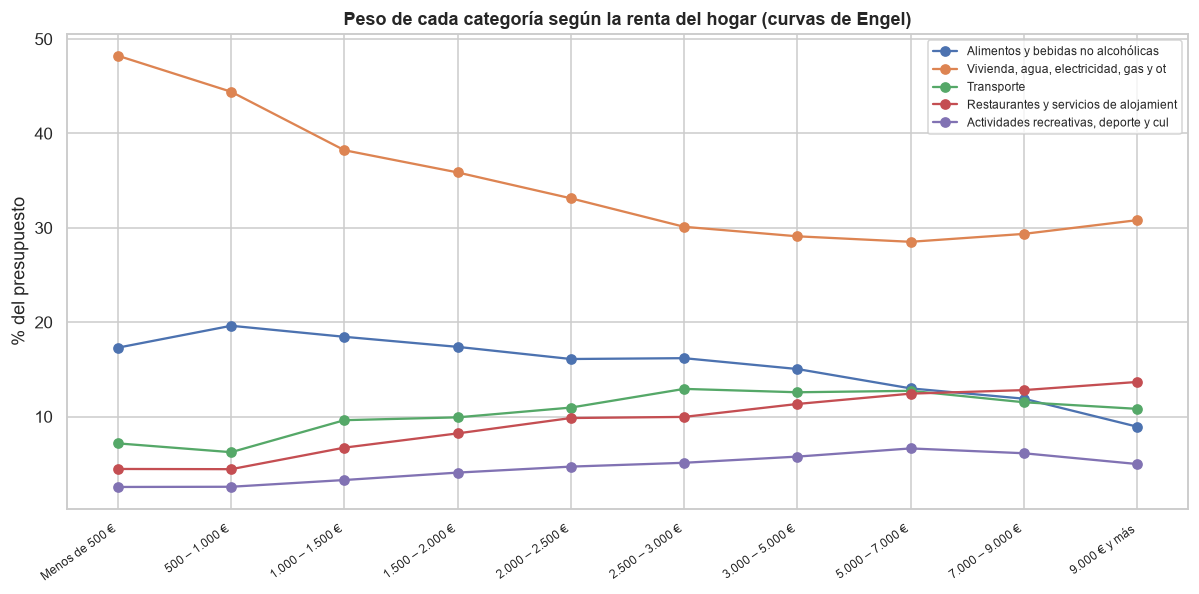

Peso alimentación renta más baja vs más alta: 17.3 % -> 8.9 %


In [7]:
piv = df.pivot_table(index="intervalo_ingresos", columns="grupo_nombre",
                     values="gasto_grupo_elev", aggfunc="sum")
share = piv.div(piv.sum(axis=1), axis=0) * 100
share = share.reindex([o for o in ORD_ING if o in share.index and o != "No consta"])
grupos_clave = ["Alimentos y bebidas no alcohólicas",
                "Vivienda, agua, electricidad, gas y otros combustibles",
                "Transporte", "Restaurantes y servicios de alojamiento",
                "Actividades recreativas, deporte y cultura"]
fig, ax = plt.subplots(figsize=(11, 5.5))
for g in grupos_clave:
    ax.plot(range(len(share)), share[g], marker="o", label=g[:38])
ax.set_xticks(range(len(share))); ax.set_xticklabels(share.index, rotation=35, ha="right", fontsize=8)
ax.set(title="Peso de cada categoría según la renta del hogar (curvas de Engel)",
       ylabel="% del presupuesto")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.savefig(FIG/"fig04_engel_ingresos.png", bbox_inches="tight"); plt.show()
print("Peso alimentación renta más baja vs más alta:",
      round(share["Alimentos y bebidas no alcohólicas"].iloc[0],1), "% ->",
      round(share["Alimentos y bebidas no alcohólicas"].iloc[-1],1), "%")

### 2.2 Gasto medio según tamaño del hogar y estudios del sustentador

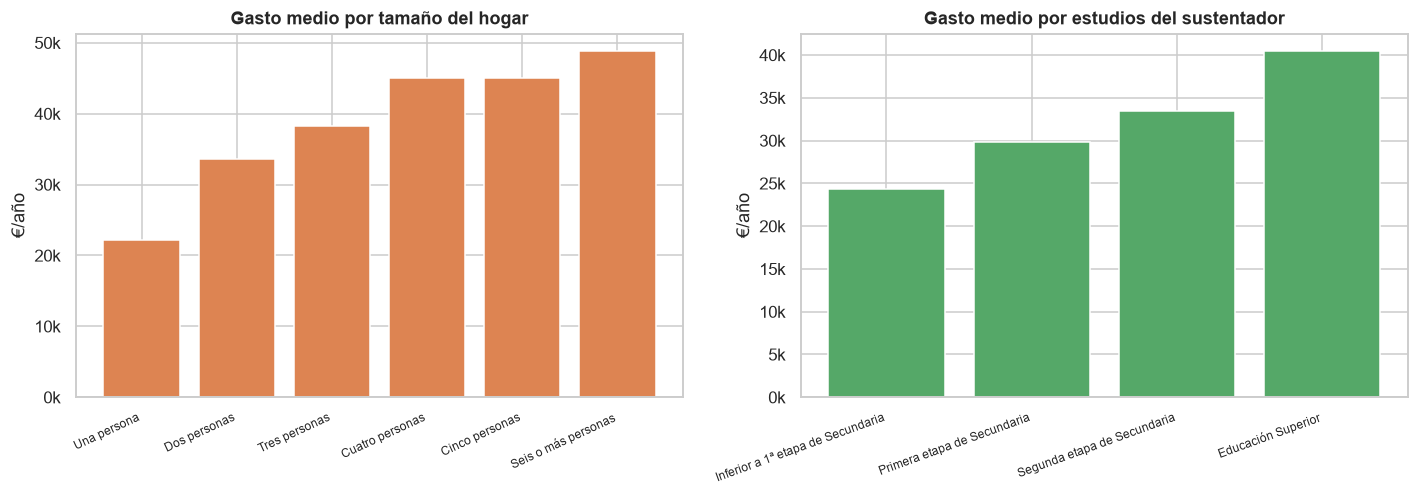

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
g1 = wmean_by(hog, "tam_hogar", "gasto_eur").reindex(ORD_TAM)
ax[0].bar(range(len(g1)), g1.values, color="#DD8452")
ax[0].set_xticks(range(len(g1))); ax[0].set_xticklabels(g1.index, rotation=25, ha="right", fontsize=8)
ax[0].set(title="Gasto medio por tamaño del hogar", ylabel="€/año")
g2 = wmean_by(hog, "estudios", "gasto_eur").reindex(ORD_EST)
ax[1].bar(range(len(g2)), g2.values, color="#55A868")
ax[1].set_xticks(range(len(g2))); ax[1].set_xticklabels(g2.index, rotation=20, ha="right", fontsize=8)
ax[1].set(title="Gasto medio por estudios del sustentador", ylabel="€/año")
for a in ax: a.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
plt.tight_layout(); plt.savefig(FIG/"fig05_gasto_por_perfil.png", bbox_inches="tight"); plt.show()

## Bloque 3 · Dimensión territorial
### 3.1 Gasto medio por comunidad autónoma

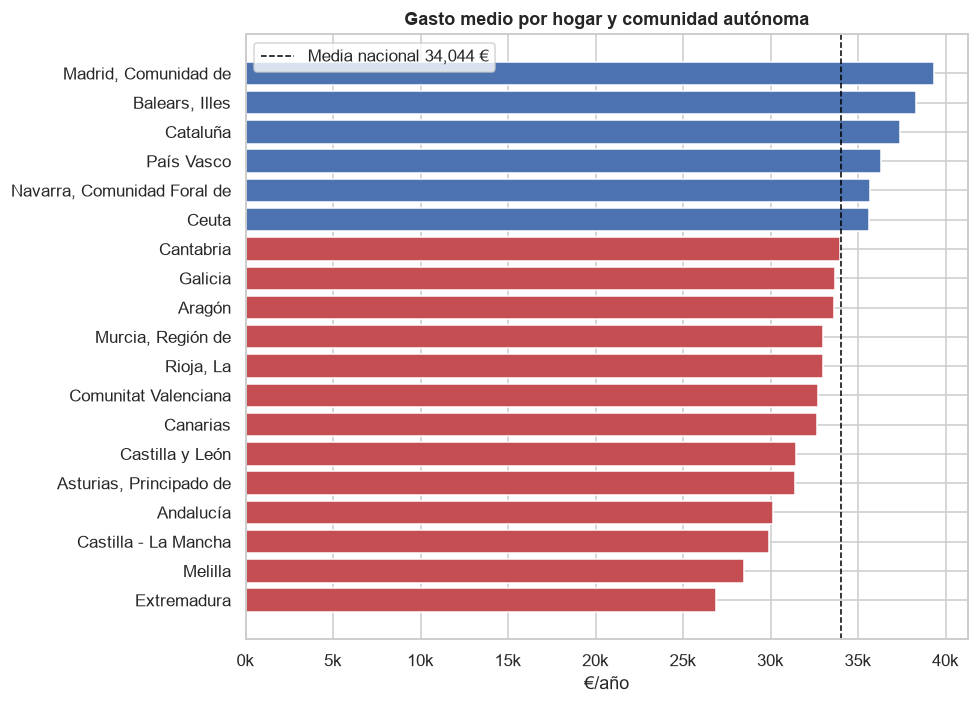

Máx: Madrid, Comunidad de 39318 | Mín: Extremadura 26890


In [9]:
ccaa_g = wmean_by(hog, "ccaa", "gasto_eur").sort_values()
fig, ax = plt.subplots(figsize=(9, 6.5))
colors = ["#C44E52" if v < media else "#4C72B0" for v in ccaa_g.values]
ax.barh(ccaa_g.index, ccaa_g.values, color=colors)
ax.axvline(media, color="black", ls="--", lw=1, label=f"Media nacional {media:,.0f} €")
ax.set(title="Gasto medio por hogar y comunidad autónoma", xlabel="€/año")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.legend()
plt.tight_layout(); plt.savefig(FIG/"fig06_gasto_por_ccaa.png", bbox_inches="tight"); plt.show()
print("Máx:", ccaa_g.idxmax(), round(ccaa_g.max()), "| Mín:", ccaa_g.idxmin(), round(ccaa_g.min()))

### 3.2 Composición del presupuesto según el tamaño del municipio

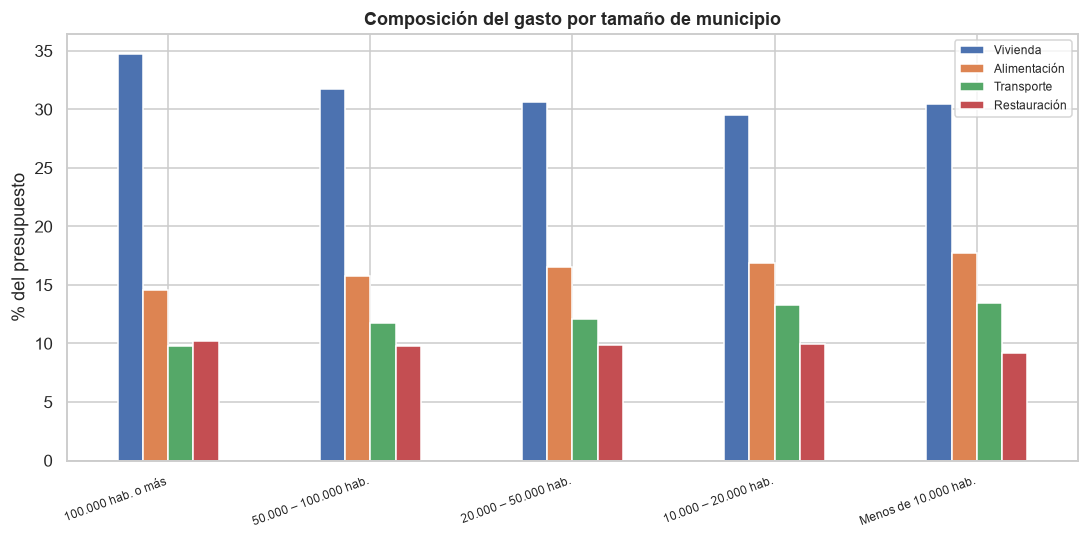

In [10]:
piv_m = df.pivot_table(index="tamano_municipio", columns="grupo_nombre",
                       values="gasto_grupo_elev", aggfunc="sum")
share_m = (piv_m.div(piv_m.sum(axis=1), axis=0) * 100).reindex(ORD_MUNI)
comp = share_m[["Vivienda, agua, electricidad, gas y otros combustibles",
                "Alimentos y bebidas no alcohólicas",
                "Transporte", "Restaurantes y servicios de alojamiento"]]
comp.columns = ["Vivienda", "Alimentación", "Transporte", "Restauración"]
fig, ax = plt.subplots(figsize=(10, 5))
comp.plot(kind="bar", ax=ax, color=["#4C72B0","#DD8452","#55A868","#C44E52"])
ax.set_xticklabels(comp.index, rotation=20, ha="right", fontsize=8)
ax.set(title="Composición del gasto por tamaño de municipio", ylabel="% del presupuesto", xlabel="")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"fig07_territorio_composicion.png", bbox_inches="tight"); plt.show()

## Bloque 4 · El cruce diferencial: consumo × inflación
### 4.1 ¿Coinciden los grupos donde más subió el IPC con los de mayor peso?

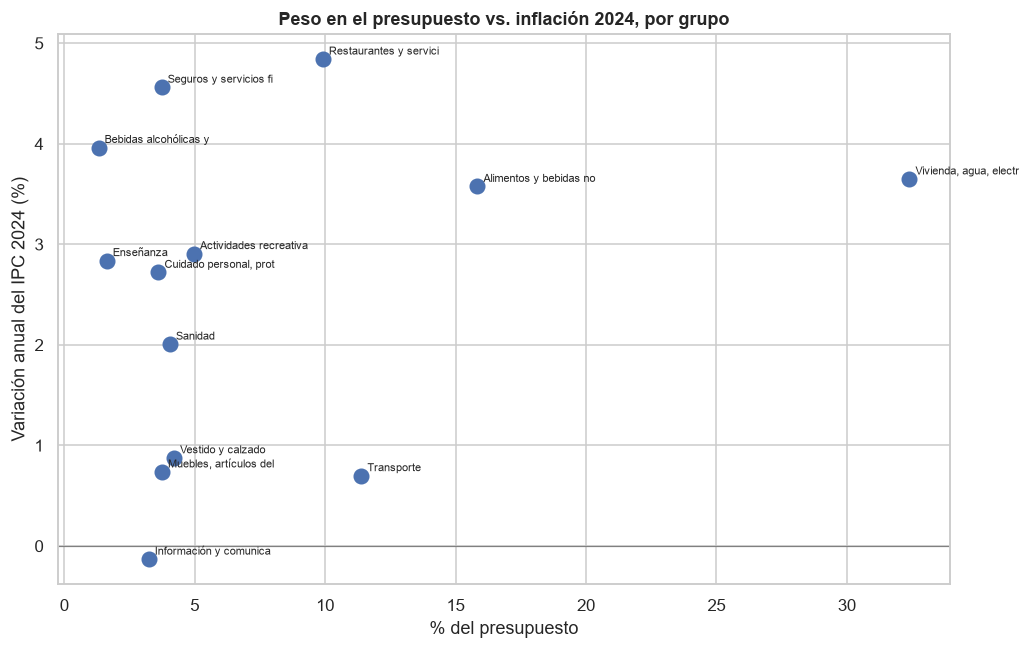

In [11]:
peso_g = df.groupby("grupo_nombre")["gasto_grupo_elev"].sum()
peso_g = peso_g / peso_g.sum() * 100
inf_g = df.groupby("grupo_nombre").apply(
    lambda d: np.average(d.ipc_var_anual_2024, weights=d.gasto_grupo_elev), include_groups=False)
comp4 = pd.DataFrame({"peso": peso_g, "inflacion": inf_g}).dropna()
fig, ax = plt.subplots(figsize=(9.5, 6))
ax.scatter(comp4.peso, comp4.inflacion, s=90, color="#4C72B0")
for g, r in comp4.iterrows():
    ax.annotate(g[:22], (r.peso, r.inflacion), fontsize=7,
                xytext=(4, 3), textcoords="offset points")
ax.axhline(0, color="grey", lw=.8)
ax.set(title="Peso en el presupuesto vs. inflación 2024, por grupo",
       xlabel="% del presupuesto", ylabel="Variación anual del IPC 2024 (%)")
plt.tight_layout(); plt.savefig(FIG/"fig08_ipc_peso_vs_inflacion.png", bbox_inches="tight"); plt.show()

### 4.2 "Inflación sentida": la subida del IPC ponderada por cómo gasta cada hogar
Para cada hogar: media de la inflación de sus categorías, ponderada por lo que
gasta realmente en cada una. Luego comparamos por nivel de renta.

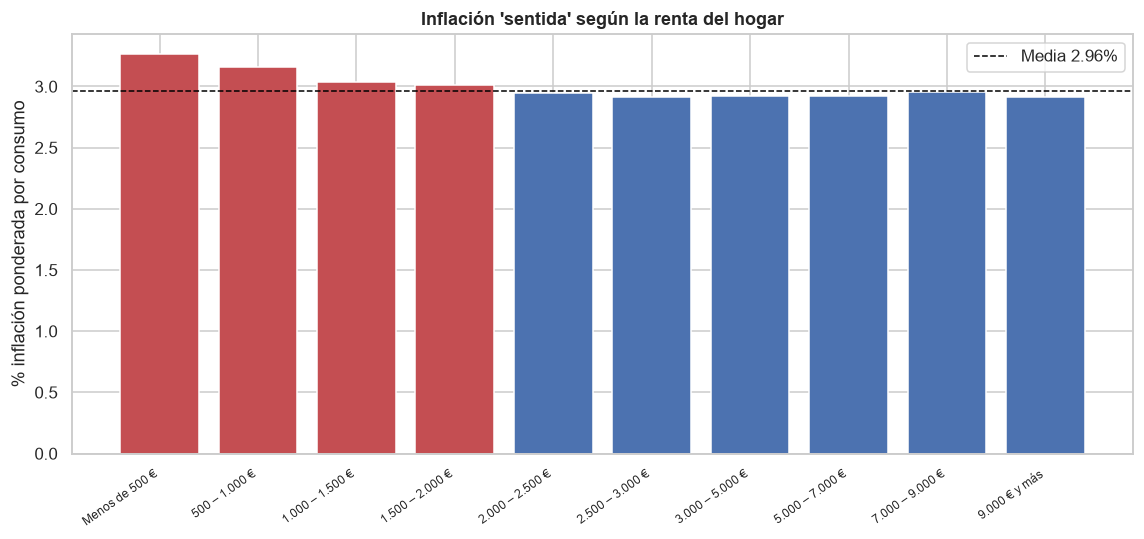

Inflación sentida — renta más baja: 3.26 % | renta más alta: 2.91 %


In [12]:
num = df.groupby("NUMERO").apply(
    lambda d: (d.gasto_grupo_eur * d.ipc_var_anual_2024).sum() / d.gasto_grupo_eur.sum(),
    include_groups=False)
hog["inf_sentida"] = hog["NUMERO"].map(num)
_c = df.assign(_ct=df.gasto_grupo_elev * df.ipc_var_anual_2024)
inf_por_renta = (_c.groupby("intervalo_ingresos", observed=True)
                   .apply(lambda d: d._ct.sum() / d.gasto_grupo_elev.sum(), include_groups=False)
                   .reindex([o for o in ORD_ING if o != "No consta"]))
media_sent = (df.gasto_grupo_elev * df.ipc_var_anual_2024).sum() / df.gasto_grupo_elev.sum()
fig, ax = plt.subplots(figsize=(10.5, 5))
colors = ["#C44E52" if v > media_sent else "#4C72B0" for v in inf_por_renta.values]
ax.bar(range(len(inf_por_renta)), inf_por_renta.values, color=colors)
ax.axhline(media_sent, color="black", ls="--", lw=1, label=f"Media {media_sent:.2f}%")
ax.set_xticks(range(len(inf_por_renta))); ax.set_xticklabels(inf_por_renta.index, rotation=35, ha="right", fontsize=8)
ax.set(title="Inflación 'sentida' según la renta del hogar", ylabel="% inflación ponderada por consumo")
ax.legend()
plt.tight_layout(); plt.savefig(FIG/"fig09_inflacion_sentida_ingresos.png", bbox_inches="tight"); plt.show()
print("Inflación sentida — renta más baja:", round(inf_por_renta.iloc[0],2),
      "% | renta más alta:", round(inf_por_renta.iloc[-1],2), "%")

## Bloque 5 · Análisis estadístico
### 5.1 Correlaciones (Spearman) entre variables del hogar

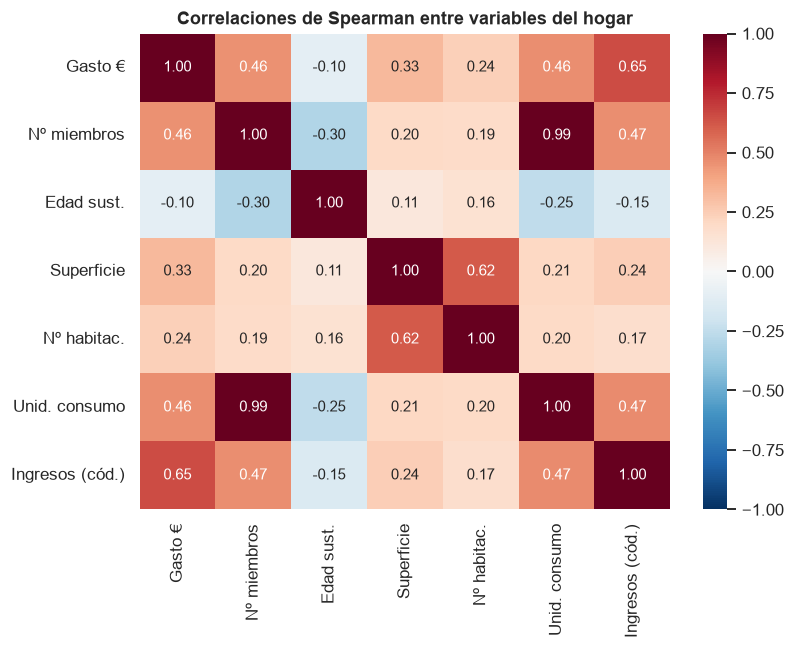

In [13]:
num_cols = {"gasto_eur":"Gasto €", "nmiemb":"Nº miembros", "edad_sp":"Edad sust.",
            "superf":"Superficie", "nhabit":"Nº habitac.", "uc1":"Unid. consumo",
            "interin_cod":"Ingresos (cód.)"}
corr = hog[list(num_cols)].rename(columns=num_cols).corr(method="spearman")
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlaciones de Spearman entre variables del hogar")
plt.tight_layout(); plt.savefig(FIG/"fig10_correlaciones.png", bbox_inches="tight"); plt.show()

### 5.2 ¿Las diferencias de gasto entre grupos son significativas?
Contraste de Kruskal-Wallis (no paramétrico, apto para gasto asimétrico) sobre
el gasto por hogar. *Nota metodológica:* los contrastes se hacen sobre la
muestra; la ponderación por `FACTOR` afecta a las estimaciones puntuales pero
no a estos tests, algo habitual y que conviene documentar.

In [14]:
def kruskal_por(col, orden=None):
    grupos = [g["gasto_eur"].values for _, g in hog.groupby(col, observed=True)]
    H, p = stats.kruskal(*grupos)
    return H, p
for col, nom in [("ingresos","intervalo de ingresos"), ("ccaa","comunidad autónoma"),
                 ("estudios","nivel de estudios"), ("tam_hogar","tamaño del hogar")]:
    H, p = kruskal_por(col)
    print(f"Gasto por {nom:22s}: H={H:,.0f}  p={p:.2e}  ->  "
          f"{'diferencias significativas' if p < 0.05 else 'sin diferencias'}")

Gasto por intervalo de ingresos : H=8,396  p=0.00e+00  ->  diferencias significativas
Gasto por comunidad autónoma    : H=609  p=1.15e-117  ->  diferencias significativas
Gasto por nivel de estudios     : H=2,391  p=0.00e+00  ->  diferencias significativas
Gasto por tamaño del hogar      : H=4,279  p=0.00e+00  ->  diferencias significativas


### 5.3 Distribución del gasto por renta (log) con el contraste anotado

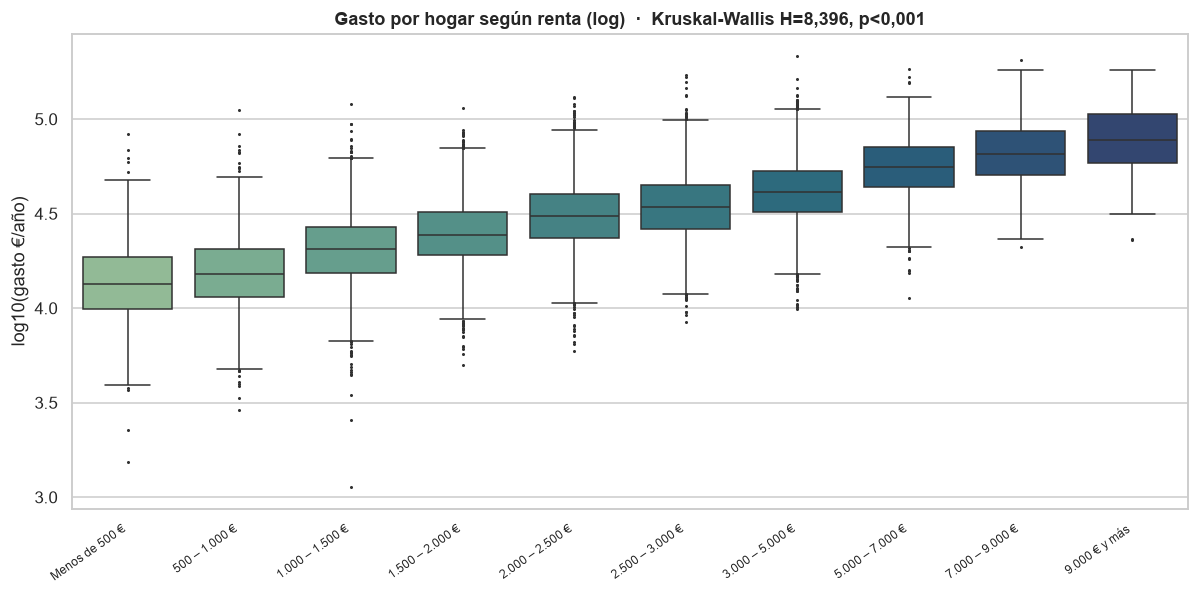


Figuras guardadas en: c:\Users\nesto\Desktop\THEPOWER\4. PROYECTOS\ThePowerRepository\Proyecto Final\DATOS\figuras


In [15]:
fig, ax = plt.subplots(figsize=(11, 5.5))
datos = hog[hog.ingresos != "No consta"].copy()
datos["ingresos"] = pd.Categorical(datos["ingresos"],
                                   [o for o in ORD_ING if o != "No consta"], ordered=True)
datos["log_gasto"] = np.log10(datos.gasto_eur)
sns.boxplot(data=datos.sort_values("ingresos"), x="ingresos", y="log_gasto",
            hue="ingresos", palette="crest", legend=False, ax=ax, fliersize=1)
plt.setp(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)
H, p = kruskal_por("ingresos")
ax.set(title=f"Gasto por hogar según renta (log)  ·  Kruskal-Wallis H={H:,.0f}, p<0,001",
       xlabel="", ylabel="log10(gasto €/año)")
plt.tight_layout(); plt.savefig(FIG/"fig11_gasto_por_renta_log.png", bbox_inches="tight"); plt.show()

print("\nFiguras guardadas en:", FIG)